In [61]:
import torch
import numpy as np
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, average_precision_score

In [39]:
class NPRTransform:
  def __call__(self, img):
    
    img_np = np.array(img).astype(np.float32)
    
    h, w = img_np.shape[:2]
    
    half = np.array(img.resize((w // 2, h // 2), Image.NEAREST))
    
    half_up = np.array(
      Image.fromarray(half).resize((w, h), Image.NEAREST)
    ).astype(np.float32)
    
    npr = img_np - half_up

    npr = npr - npr.min()
    npr = npr / (npr.max() + 1e-8) * 255
    npr = Image.fromarray(npr.astype(np.uint8))
    
    return npr  

In [40]:
transform = transforms.Compose([
  transforms.Resize((224, 224)),
  NPRTransform(),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [41]:
train_dataset = ImageFolder(
  root = "images/train",
  transform = transform
)

print("Number of images:", len(train_dataset))
print("Classes:", train_dataset.classes)
print("Class to label mapping:", train_dataset.class_to_idx)

Number of images: 19
Classes: ['fake', 'real']
Class to label mapping: {'fake': 0, 'real': 1}


In [42]:
train_loader = DataLoader(
  train_dataset,
  batch_size = 4,
  shuffle = True
)

print("Number of batches:", len(train_loader))

Number of batches: 5


In [43]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels:", labels)

Batch image shape: torch.Size([4, 3, 224, 224])
Batch labels: tensor([0, 1, 1, 1])


# NPR transform visualization

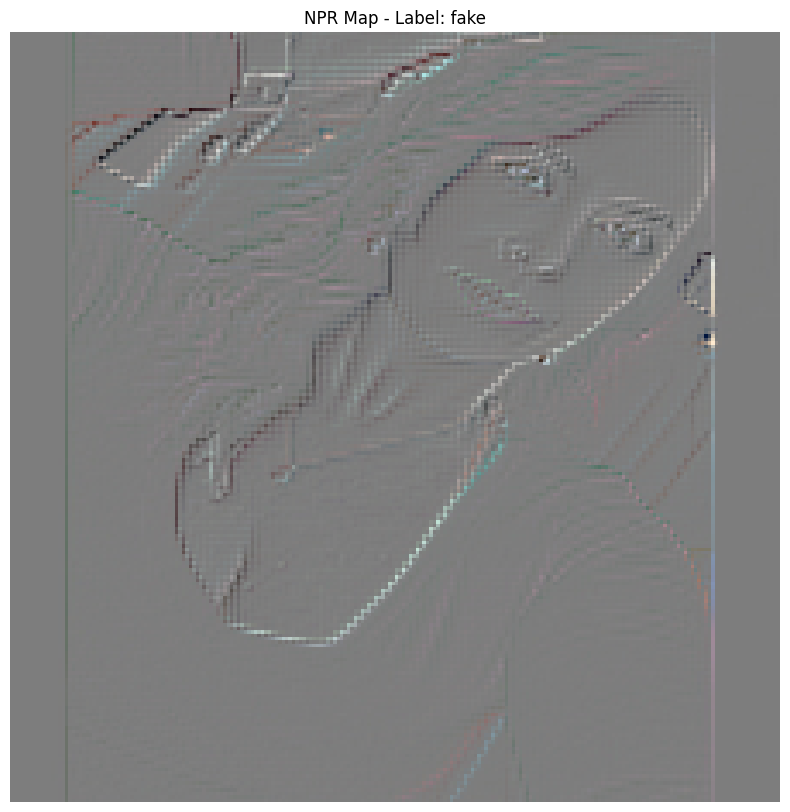

In [44]:
idx = 0
img = images[idx]
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_display = img * std + mean
img_display = img_display.clamp(0, 1)

img_display = img_display.permute(1, 2, 0).numpy()

plt.figure(figsize = (10, 10))
plt.imshow(img_display)
plt.title(f"NPR Map - Label: {'real' if labels[idx] == 1 else 'fake'}")
plt.axis('off')
plt.show()

# Training RESNET-50

In [45]:
model = models.resnet50(weights=None)

In [46]:
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [47]:
model.fc = nn.Linear(in_features=2048, out_features=1)

In [48]:
model.eval()

with torch.no_grad():
  output = model(images)
  
print("Output Shape:", output.shape)
print("Output Values:", output)

Output Shape: torch.Size([4, 1])
Output Values: tensor([[-2.9132],
        [-3.8049],
        [-3.0706],
        [-2.7479]])


In [49]:
probabilities = torch.sigmoid(output)
print("Probabilities: ", probabilities)

predictions = (probabilities > 0.5).int()

print("Predictions:", predictions)
print("Actual Labels:", labels)

Probabilities:  tensor([[0.0515],
        [0.0218],
        [0.0443],
        [0.0602]])
Predictions: tensor([[0],
        [0],
        [0],
        [0]], dtype=torch.int32)
Actual Labels: tensor([0, 1, 1, 1])


In [51]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0002)

Epoch 1/10 - Loss: 0.1152
Epoch 2/10 - Loss: 0.0095
Epoch 3/10 - Loss: 0.1840
Epoch 4/10 - Loss: 0.0250
Epoch 5/10 - Loss: 0.0155
Epoch 6/10 - Loss: 0.1361
Epoch 7/10 - Loss: 0.0322
Epoch 8/10 - Loss: 0.0080
Epoch 9/10 - Loss: 1.3214
Epoch 10/10 - Loss: 0.0673


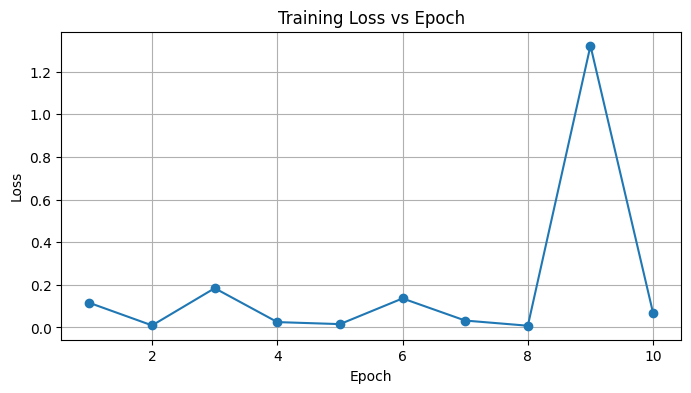

In [60]:
NUM_EPOCH = 10
losses = []

for epoch in range(NUM_EPOCH):
  model.train()
  running_loss = 0.0
  
  for images, labels in train_loader:
    labels = labels.float().unsqueeze(1)
    
    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()
    
    running_loss += loss.item()
    
  avg_loss = running_loss / len(train_loader)
  losses.append(avg_loss)
  print(f"Epoch {epoch+1}/{NUM_EPOCH} - Loss: {avg_loss:.4f}")
  
plt.figure(figsize=(8,4))
plt.plot(range(1, NUM_EPOCH+1), losses, marker = 'o')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Evaluation

In [62]:
test_dataset = ImageFolder(root = "images/test", transform = transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle = False)

print("Test Images:", len(test_dataset))

Test Images: 6


In [63]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
  for images, labels in test_loader:
    output = model(images)
    probs = torch.sigmoid(output).squeeze(1)
    
    all_labels.extend(labels.numpy())
    all_probs.extend(probs.numpy())
    
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

predictions = (all_probs > 0.5).astype(int)
accuracy = accuracy_score(all_labels, predictions)
ap = average_precision_score(all_labels, all_probs)

print(f"Accuracy: {accuracy*100:.1f}%")
print(f"Avg Precision: {ap*100:.1f}%")

Accuracy: 50.0%
Avg Precision: 58.9%


# Testing actual data/datasets

In [1]:
import importlib
import data.datasets as datasets
importlib.reload(datasets)

train_loader, train_dataset = datasets.get_dataloader("images/train", batch_size=4, shuffle=True)

images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Labels:", labels)
print("Classes:", train_dataset.classes)

Batch shape: torch.Size([4, 3, 224, 224])
Labels: tensor([0, 1, 0, 1])
Classes: ['fake', 'real']


# testing networks/resnet

In [2]:
import networks.resnet as resnet
importlib.reload(resnet)

model = resnet.get_model()

print(model.fc)

Linear(in_features=2048, out_features=1, bias=True)
